In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(1337)
np.random.seed(1337)

In [55]:
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1337)

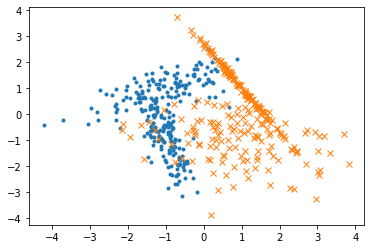

In [56]:
o_idxs = [i for i in range(y.shape[0]) if y[i] == 0]
x_idxs = [i for i in range(y.shape[0]) if y[i] == 1]
plt.plot(X[o_idxs, 0], X[o_idxs, 1], '.')
plt.plot(X[x_idxs, 0], X[x_idxs, 1], 'x')

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

In [58]:
scaler_X = StandardScaler().fit(X_train)
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [59]:
class LogisticRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

In [60]:
model = LogisticRegression(n_features=X_train.shape[1])
criteria = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

In [61]:
epoche = 200

for ep in range(epoche):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criteria(logits, y_train_t) / X_train.shape[0]
    loss.backward()
    optimizer.step()
    if (ep + 1) % 25 == 0:
        print(f"Epoche #{ep+1:03}/{epoche} - Loss (BCE): {loss.item():.4f}")

Epoche #025/200 - Loss (BCE): 0.0011
Epoche #050/200 - Loss (BCE): 0.0008
Epoche #075/200 - Loss (BCE): 0.0008
Epoche #100/200 - Loss (BCE): 0.0007
Epoche #125/200 - Loss (BCE): 0.0007
Epoche #150/200 - Loss (BCE): 0.0007
Epoche #175/200 - Loss (BCE): 0.0007
Epoche #200/200 - Loss (BCE): 0.0007


In [62]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    loss_test = criteria(logits_test, y_test_t) / X_test.shape[0]
    probs = torch.sigmoid(logits_test)
    predicted_class = (probs >= 0.5).float()
    acc = (predicted_class == y_test_t).float().mean().item()
    print(f"Test BCE: {loss_test.item():.4f}")
    print(f"Accuracy: {acc*100:.2f}%")

Test BCE: 0.0024
Accuracy: 93.00%


### Reality

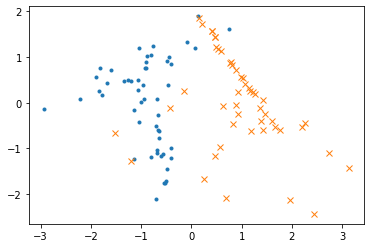

In [76]:
o_idxs = [i for i in range(y_test_t.shape[0]) if y_test_t[i] == 0]
x_idxs = [i for i in range(y_test_t.shape[0]) if y_test_t[i] == 1]
plt.plot(X_test_t[o_idxs, 0], X_test_t[o_idxs, 1], '.')
plt.plot(X_test_t[x_idxs, 0], X_test_t[x_idxs, 1], 'x')

### Prediction

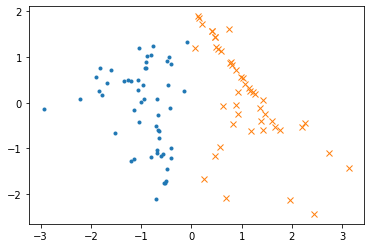

In [75]:
o_idxs = [i for i in range(y_test_t.shape[0]) if predicted_class[i] == 0]
x_idxs = [i for i in range(y_test_t.shape[0]) if predicted_class[i] == 1]
plt.plot(X_test_t[o_idxs, 0], X_test_t[o_idxs, 1], '.')
plt.plot(X_test_t[x_idxs, 0], X_test_t[x_idxs, 1], 'x')

## One-vs-Rest

In [5]:
from sklearn.preprocessing import label_binarize

In [8]:
N_CLASSES = 4

In [57]:
X, y = make_classification(n_samples=500, n_features=6, n_informative=5, n_redundant=0, n_classes=N_CLASSES, class_sep=2.5, random_state=1337)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1337)

In [59]:
X_scaler = StandardScaler().fit(X_train)
X_train = X_scaler.transform(X_train)
X_test = X_scaler.transform(X_test)

In [60]:
# One-Hot Enc
y_train_ovr = label_binarize(y_train, classes=list(range(N_CLASSES)))
y_test_ovr = label_binarize(y_test, classes=list(range(N_CLASSES)))

In [61]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train_ovr, dtype=torch.float32)
y_test_t = torch.tensor(y_test_ovr, dtype=torch.float32)
y_test_original = torch.tensor(y_test, dtype=torch.long)

In [62]:
class OneVsRestNN(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, x):
        return self.linear(x)

In [63]:
model = OneVsRestNN(n_features=X_train.shape[1], n_classes=N_CLASSES)
criteria = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

In [64]:
epoche = 1000

for ep in range(epoche):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criteria(logits, y_train_t) / y_train_t.shape[0]
    loss.backward()
    optimizer.step()
    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"Epoche #{ep+1:04}/{epoche} - Loss (BCE): {loss.item():.4f}")

Epoche #0001/1000 - Loss (BCE): 0.0019
Epoche #0100/1000 - Loss (BCE): 0.0006
Epoche #0200/1000 - Loss (BCE): 0.0005
Epoche #0300/1000 - Loss (BCE): 0.0005
Epoche #0400/1000 - Loss (BCE): 0.0005
Epoche #0500/1000 - Loss (BCE): 0.0005
Epoche #0600/1000 - Loss (BCE): 0.0005
Epoche #0700/1000 - Loss (BCE): 0.0005
Epoche #0800/1000 - Loss (BCE): 0.0005
Epoche #0900/1000 - Loss (BCE): 0.0005
Epoche #1000/1000 - Loss (BCE): 0.0005


In [65]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    loss_test = criteria(logits_test, y_test_t) / y_test_t.shape[0]
    probs = torch.sigmoid(logits_test)
    predicted_class = torch.argmax(probs, dim=1)
    acc = (predicted_class == y_test_original).float().mean().item()
    print(f"BCE Loss: {loss_test:.4f}")
    print(f"Accuracy: {acc*100:.2f}%")

BCE Loss: 0.0018
Accuracy: 87.00%


### Visualization

In [88]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA

In [89]:
pca = PCA(n_components=2, random_state=1337)
X_pca = pca.fit_transform(X_train)

In [90]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train, y_train)

In [91]:
print(f"PCA Variance: {sum(pca.explained_variance_ratio_)}")
print(f"LDA Variance: {sum(lda.explained_variance_ratio_)}")

PCA Variance: 0.5627230238763925
LDA Variance: 0.9312383166680543


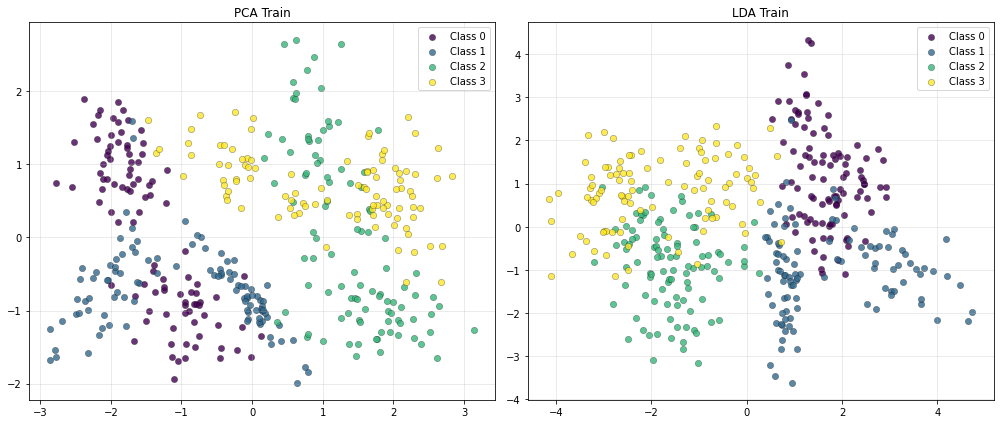

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
colors = plt.cm.viridis(np.linspace(0,1,N_CLASSES))

for clas in range(N_CLASSES):
    mask = y_train == clas
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[clas], label=f"Class {clas}", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1], color=colors[clas], label=f"Class {clas}", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)

axes[0].set_title("PCA Train")
axes[1].set_title("LDA Train")
axes[0].legend()
axes[1].legend()
axes[0].grid(alpha=.3)
axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

In [93]:
pca = PCA(n_components=2, random_state=1337)
X_pca_test = pca.fit_transform(X_test)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda_test = lda.fit_transform(X_test, y_test)

In [94]:
print(f"PCA Variance: {sum(pca.explained_variance_ratio_)}")
print(f"LDA Variance: {sum(lda.explained_variance_ratio_)}")

PCA Variance: 0.5781631076634952
LDA Variance: 0.8962480618645345


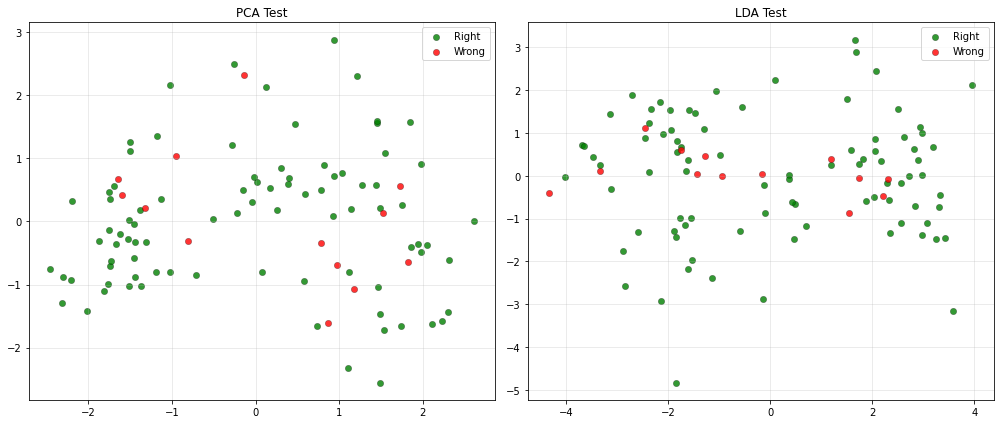

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

right = predicted_class == y_test_original
wrong = predicted_class != y_test_original
axes[0].scatter(X_pca_test[right, 0], X_pca_test[right, 1], color='g', label=f"Right", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)
axes[0].scatter(X_pca_test[wrong, 0], X_pca_test[wrong, 1], color='r', label=f"Wrong", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)
axes[1].scatter(X_lda_test[right, 0], X_lda_test[right, 1], color='g', label=f"Right", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)
axes[1].scatter(X_lda_test[wrong, 0], X_lda_test[wrong, 1], color='r', label=f"Wrong", alpha=0.8, edgecolors='k', linewidths=0.3, s=40)

axes[0].set_title("PCA Test")
axes[1].set_title("LDA Test")
axes[0].legend()
axes[1].legend()
axes[0].grid(alpha=.3)
axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()